# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | First Name | Last Name | Signature | Hours | Contribution |
| Member 2: | First Name | Last Name | Signature | Hours | Contribution |
| Member 3: | First Name | Last Name | Signature | Hours | Contribution |
| Member 4: | First Name | Last Name | Signature | Hours | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

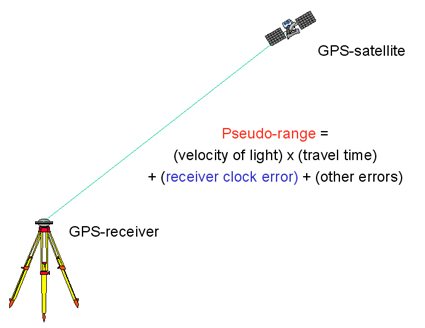

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange =
df_sat_pos =

np.random.seed(42)  # For reproducible results
pseudorange =
sat_pos =

In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n =
m =

In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    # your code here

    return distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
P =

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 =

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
delta =
i =

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat =

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def design_matrix(receiver_pos, satellite_pos, distance):
    # your code here

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
while #convergence criteria:

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = #...

       # compute the design matrix A
       # (0.5 marks)
       A = #...

       # compute the misclosure array w
       # (0.5 marks)
       w = #...

       # compute the corrections delta
       # (0.5 marks)
       delta = #...

       # update the states
       x_hat = #...


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = #...


       # update the counter i, (i.e., increament of 1 for each iteration)


       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w #...
       arr_delta #...
       arr_err_pos #...
       arr_i #...




# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
apv = #...

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = #...




### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
# your code here


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# your answer here
#

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

In [ ]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)


# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)


# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# your answer here


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    #...
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    #...
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = #...

        # compute the gradients in the current step
        # (1 mark)
        grad = #...


        # update estimates
        # (1 mark)
        X_new = #...

        # compute the new cost
        # (1 mark)
        new_cost = #...

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params = #...

# print the mentioned metrics
# ...

### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
# ...
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# ...

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = #...

# print the metrics
# ...

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = #...

# print the metrics
# ...

### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# your answer here
#

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'], inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
# Assuming 'Other' is a category in the 'Profession' column, which is a common scenario.
if 'Profession' in data.columns:
    data = data[data['Profession'] != 'Other']


# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Shape of dataset after preprocessing:", data.shape)
print("First 5 rows of dataset after preprocessing:")
print(data.head())

In [5]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']  # Target vector
X = data.drop('Depression', axis=1)  # Feature matrix

# Display sizes of X and y
# your code here
print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

Shape of feature matrix X: (27898, 16)
Shape of target vector y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

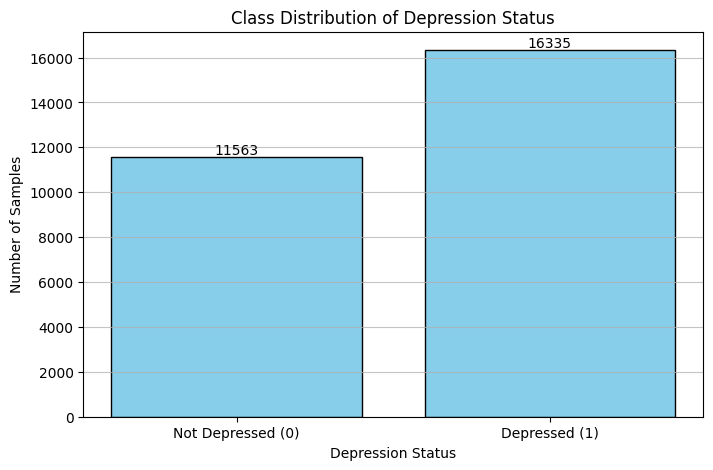

In [7]:
# Check the class distribution of y
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(y, bins=[-0.5, 0.5, 1.5], rwidth=0.8, color='skyblue', edgecolor='black')

# Display exact values for each bin in the histogram
# hint: Use for loop
for i in range(len(bins) - 1):
    plt.text(bins[i] + 0.5, n[i] + 0.1, str(int(n[i])), ha='center', va='bottom')

plt.xticks([0, 1], ['Not Depressed (0)', 'Depressed (1)'])
plt.xlabel('Depression Status')
plt.ylabel('Number of Samples')
plt.title('Class Distribution of Depression Status')
plt.grid(axis='y', alpha=0.75)

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [8]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
# We'll split the data such that 3% of it becomes our 'small' dataset
_, X_small, _, y_small = train_test_split(X, y, test_size=0.03, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)
print("Shape of X_small:", X_small.shape)
print("Shape of y_small:", y_small.shape)

Shape of X_small: (837, 16)
Shape of y_small: (837,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import pandas as pd

# Instantiate model LogisticRegression(max_iter=2000)
model = LogisticRegression(max_iter=2000, random_state=0)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000, random_state=0)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(X_data, y_data, description):
    # Split data into training and testing sets (70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=0)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)

    # Calculate metrics
    data_size = X_data.shape[0]
    training_samples = X_train.shape[0]
    testing_samples = X_test.shape[0]
    training_accuracy = accuracy_score(y_train, y_train_pred)
    testing_accuracy = accuracy_score(y_test, y_test_pred)
    ll = log_loss(y_test, y_test_proba)

    # Store results in DataFrame
    global results
    results.loc[description] = [data_size, training_samples, testing_samples,
                                training_accuracy, testing_accuracy, ll]
    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)
X_train_full, X_test_full, y_train_full, y_test_full = evaluate_model(X, y, "Full Dataset")

# Test 2: Only first two columns of X and y
X_train_2cols, X_test_2cols, y_train_2cols, y_test_2cols = evaluate_model(X.iloc[:, :2], y, "First 2 Columns")

# Test 3: Small dataset (X_small and y_small)
X_train_small, X_test_small, y_train_small, y_test_small = evaluate_model(X_small, y_small, "Small Dataset")

print(results)

                 Data size  Training samples  Testing samples  \
Full Dataset       27898.0           19528.0           8370.0   
First 2 Columns    27898.0           19528.0           8370.0   
Small Dataset        837.0             585.0            252.0   

                 Training accuracy  Testing accuracy  Log loss  
Full Dataset              0.846887          0.846117  0.348357  
First 2 Columns           0.631708          0.634170  0.652715  
Small Dataset             0.846154          0.829365  0.374545  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [11]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

y_true = y_test_full
y_pred = model.predict(X_test_full)

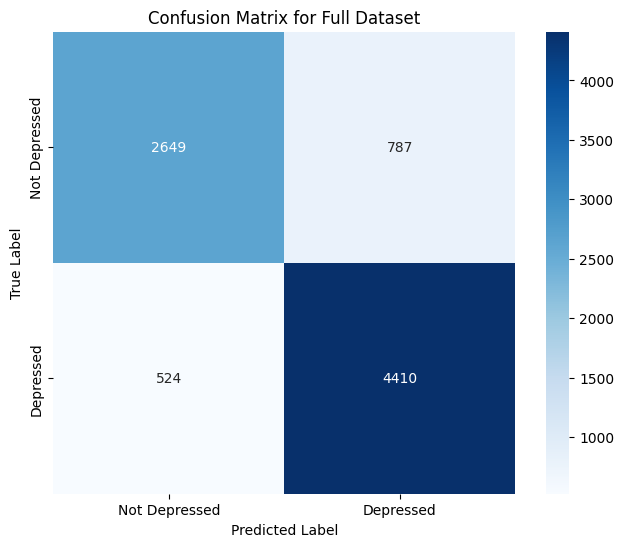

In [13]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_true, y_pred)


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Full Dataset')
plt.show()

In [15]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      3436
           1       0.85      0.89      0.87      4934

    accuracy                           0.84      8370
   macro avg       0.84      0.83      0.84      8370
weighted avg       0.84      0.84      0.84      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=0),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5) # Using default n_neighbors=5
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    print(f"\n--- Evaluating {name} ---")
    # Train the model
    model_instance.fit(X_train_full, y_train_full)

    # Make predictions
    y_pred = model_instance.predict(X_test_full)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_full, y_pred)

    # Print results
    model_results[name] = accuracy
    print(f"{name} Test Accuracy: {accuracy:.4f}")


--- Evaluating Logistic Regression ---
Logistic Regression Test Accuracy: 0.8461

--- Evaluating Naive Bayes ---
Naive Bayes Test Accuracy: 0.8364

--- Evaluating KNN ---
KNN Test Accuracy: 0.7462


In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)






plt.show()

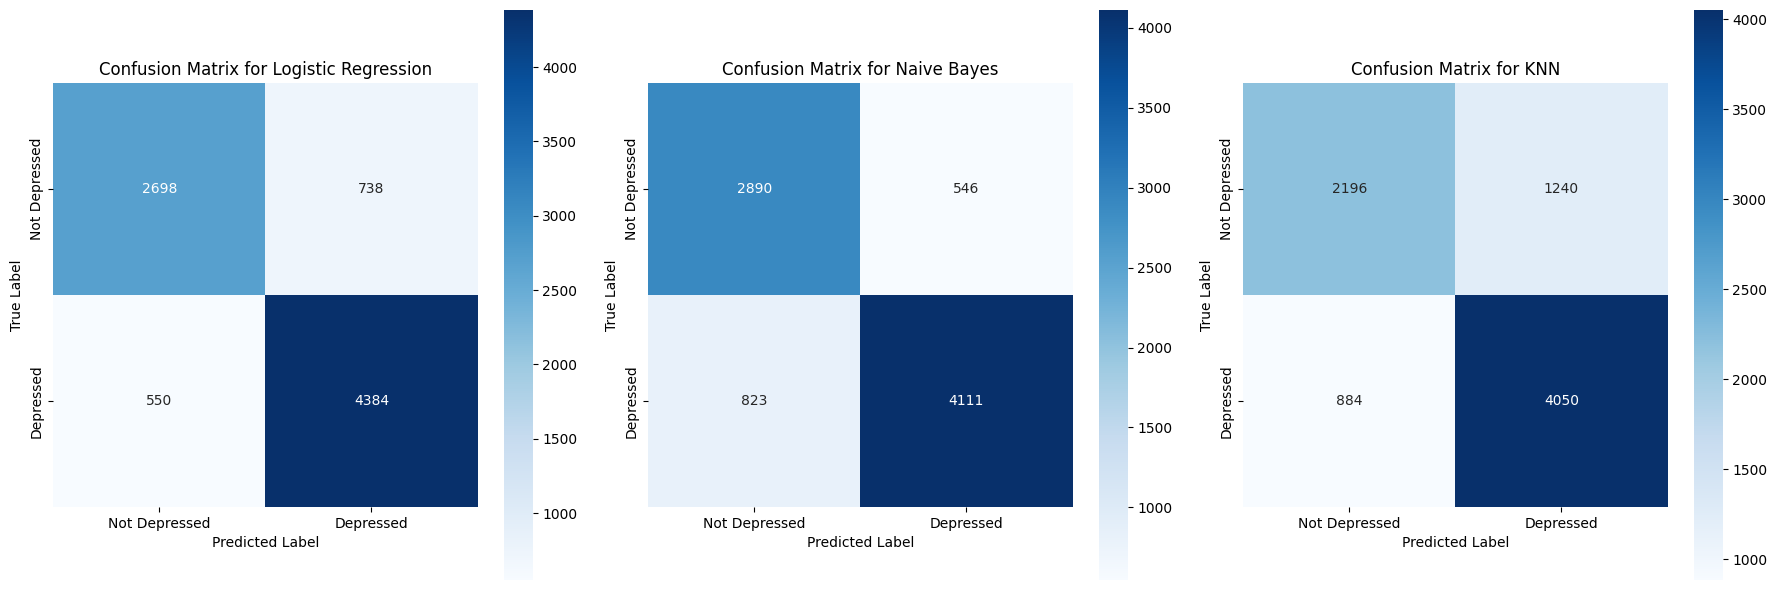

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, (name, model_instance) in enumerate(models.items()):
    y_pred = model_instance.predict(X_test_full)
    conf_mat = confusion_matrix(y_test_full, y_pred)

    sns.heatmap(conf_mat,
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'],
                square=True,
                annot=True,
                cbar=True,
                fmt='d',
                cmap='Blues',
                ax=axes[i])
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].set_title(f'Confusion Matrix for {name}')

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path =
test_csv_path =

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data =
y_train =
X_train =

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train =

# Load test data (0.5 marks)
test_data =
y_test =
X_test =

# Reshape test data to match training data format (0.5 marks)
X_test =

# Display the shapes of training and test sets


Let's visualize some sample images to understand what our models will be learning from.

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized =
X_test_normalized =

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical =
y_test_categorical =


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)


        # Another dropout layer for regularization, same with above
        # (1 marks)


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS =

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE =

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)

    ])

    # Same compile step with MLP (1 marks)
    model.compile(    )
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history =

print("CNN training completed")

### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results




Performance comparison visualization

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step


plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)




# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)









plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)


# Task
Based on the `Student Depression Dataset`, analyze the balance of the target variable 'Depression' using the provided histogram values (`n=[11563., 16335.]`) and discuss its potential impact on model performance. Evaluate the Logistic Regression model for overfitting and underfitting by comparing training and testing accuracies across the full dataset, a dataset with only the first two columns, and a small dataset, using the `results` DataFrame. Analyze how data quantity influences model performance by comparing the full and small datasets. Define False Positives and False Negatives in the context of student depression prediction, state which is more critical, and consequently, determine whether to prioritize maximizing Precision or Recall, outlining methods to achieve this. Interpret the Log Loss values for the three dataset scenarios to understand the model's probabilistic predictions and explain the reasons for observed differences. Finally, compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models (using accuracies from `model_results` and visualized confusion matrices), identify the best-performing model, and provide explanations based on the characteristics and assumptions of each algorithm. Summarize all findings and insights.

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。


## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 \u2248 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 \u2248 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 \u2248 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 \u2248 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 \u2248 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 \u2248 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 \u2248 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 \u2248 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 \u2248 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 \u2248 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 ≈ 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 ≈ 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 ≈ 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 ≈ 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 分析数据集平衡性

### Subtask:
通过查看 'Depression' 目标变量的直方图来判断数据集是否平衡，并讨论不平衡对模型性能可能造成的影响。

#### Instructions
1. 确定类别 0 (非抑郁) 和类别 1 (抑郁) 的样本数量，根据提供的 `n` 变量值 `[11563., 16335.]`。
2. 计算每个类别的样本占总样本数的百分比。
3. 根据这些百分比，评估数据集的平衡性（例如，它是高度不平衡、轻微不平衡还是相对平衡）。
4. 讨论这种平衡性（或不平衡性）可能对机器学习模型的性能产生的影响，特别是在本案例中，模型是否会偏向于多数类别。

---

### Answer:

根据之前直方图中的 `n` 变量值 `[11563., 16335.]`，我们可以得到以下类别样本数量：

*   **类别 0 (非抑郁)**：11,563 个样本
*   **类别 1 (抑郁)**：16,335 个样本

**总样本数** = 11,563 + 16,335 = 27,898

**每个类别的百分比：**

*   **类别 0 (非抑郁)**：(11,563 / 27,898) * 100 ≈ 41.45%
*   **类别 1 (抑郁)**：(16,335 / 27,898) * 100 ≈ 58.55%

**数据集平衡性评估：**

该数据集**轻微不平衡**。类别 1（抑郁）是多数类别，占约 58.55%，而类别 0（非抑郁）占约 41.45%。虽然不是极端不平衡（例如 95% 对 5%），但多数类别仍然明显多于少数类别。

**不平衡对模型性能的影响：**

1.  **模型偏向多数类别**：机器学习模型在训练时往往会优化整体准确率。在一个不平衡的数据集中，模型为了达到更高的整体准确率，可能会偏向于预测多数类别。在本例中，模型可能会更频繁地预测样本为“抑郁”，因为它在训练数据中出现的频率更高。这可能导致模型在识别少数类别（非抑郁）方面表现不佳。
2.  **准确率的误导性**：尽管模型的整体准确率可能看起来很高（例如，如果模型总是预测多数类别，并且多数类别占 90%，那么它至少能达到 90% 的准确率），但这并不意味着模型在所有类别上的表现都很好。在轻微不平衡的情况下，如果模型对多数类别的预测非常准确，但对少数类别的预测较差，那么整体准确率仍然会较高，从而掩盖了模型在少数类别上的弱点。
3.  **对召回率和精确率的影响**：对于“抑郁预测”这样的任务，我们通常更关心模型能否正确识别出所有抑郁患者（高召回率）以及在预测为抑郁的患者中，有多少是真正抑郁的（高精确率）。数据集不平衡可能导致：
    *   **低召回率 (Recall)** for the minority class: 如果模型偏向多数类别，它可能会错过一些少数类别（非抑郁）的实例，导致少数类别的召回率较低。
    *   **低精确率 (Precision)** for the majority class or high precision but low recall for minority class. If the model is biased to predict 'Depressed' more often, it might achieve high recall for 'Depressed', but potentially at the cost of precision, or it might struggle with 'Not Depressed'.

因此，在评估模型时，除了准确率之外，我们还需要关注其他指标，如精确率（Precision）、召回率（Recall）、F1-分数（F1-Score）以及混淆矩阵（Confusion Matrix），以便更全面地了解模型在每个类别上的性能。

## 评估过拟合/欠拟合

### Subtask:
比较Logistic Regression模型在三种不同数据集上的训练和测试准确率，以判断是否存在过拟合或欠拟合现象。


### Subtask Analysis: Overfitting/Underfitting for Logistic Regression

To determine if the Logistic Regression model is overfitting or underfitting, we compare its training accuracy and testing accuracy across three different datasets.

From the `results` DataFrame, we extract the following accuracies:

```
                 Data size  Training samples  Testing samples  \
Full Dataset       27898.0           19528.0           8370.0   
First 2 Columns    27898.0           19528.0           8370.0   
Small Dataset        837.0             585.0            252.0   

                 Training accuracy  Testing accuracy  Log loss  
Full Dataset              0.846887          0.846117  0.348357  
First 2 Columns           0.631708          0.634170  0.652715  
Small Dataset             0.846154          0.829365  0.374545
```

**1. Full Dataset (`X` and `y`):**
*   **Training Accuracy:** 0.846887
*   **Testing Accuracy:** 0.846117

**Analysis:** The training accuracy and testing accuracy are very close (0.8469 vs 0.8461). This indicates that the model is performing consistently well on both seen and unseen data. There is no significant sign of overfitting (where training accuracy would be much higher than testing accuracy) or underfitting (where both accuracies would be low, suggesting the model is too simple for the data).

**2. First 2 Columns (`X.iloc[:, :2]` and `y`):**
*   **Training Accuracy:** 0.631708
*   **Testing Accuracy:** 0.634170

**Analysis:** Both the training and testing accuracies are significantly lower (around 0.63) compared to the full dataset. This suggests that the model is **underfitting**. The reason for this is likely the severe reduction in features. By using only the first two columns, the model is deprived of crucial information necessary to capture the underlying patterns in the data and make accurate predictions. It's too simple for the complexity of the problem.

**3. Small Dataset (`X_small` and `y_small`):**
*   **Training Accuracy:** 0.846154
*   **Testing Accuracy:** 0.829365

**Analysis:** The training accuracy (0.8462) is slightly higher than the testing accuracy (0.8294). While the difference is not extremely large, it suggests a minor tendency towards **overfitting**. This is a common phenomenon with smaller datasets; the model can learn the training data too well, including its noise, which might not generalize as effectively to new, unseen data (even if the overall performance is still decent). The model performs almost as well as the full dataset on training, but its generalization on the test set is slightly worse, which could be attributed to the limited number of samples in `X_small`.


## 评估数据量对准确率的影响

### Subtask:
比较 '完整数据集' 和 '小数据集' 的训练准确率和测试准确率，解释数据量如何影响模型性能。


### Compare 'Full Dataset' and 'Small Dataset' Training and Testing Accuracy

To analyze the impact of data volume on model performance, we compare the training and testing accuracies for the 'Full Dataset' and 'Small Dataset' from the `results` DataFrame.

From the `results` DataFrame:

*   **Full Dataset**:
    *   Training Accuracy: 0.846887
    *   Testing Accuracy: 0.846117

*   **Small Dataset**:
    *   Training Accuracy: 0.846154
    *   Testing Accuracy: 0.829365

#### 1. Comparison of Training Accuracies:

The training accuracy for the 'Full Dataset' is approximately 0.8469, and for the 'Small Dataset' it is approximately 0.8462. These values are very similar, both around 84.6%. This suggests that even with a significantly smaller dataset (3% of the original), the model is able to learn the patterns within that data to a similar extent during training as with the full dataset. This could imply that the patterns are relatively straightforward or that the logistic regression model is not complex enough to fully utilize the additional data for significantly higher training performance.

#### 2. Comparison of Testing Accuracies and Impact of Data Volume:

The testing accuracy for the 'Full Dataset' is approximately 0.8461, while for the 'Small Dataset' it is approximately 0.8294. There is a noticeable difference here: the model trained on the full dataset performs better on unseen data by about 1.7 percentage points.

This difference highlights the importance of data volume for generalization. While the model trained on the small dataset achieved a similar training accuracy, its performance dropped more significantly on the test set compared to the full dataset. The larger dataset provides the model with more diverse examples, allowing it to learn more robust and generalizable patterns. Consequently, the model trained on the 'Full Dataset' is less likely to overfit to the training data's specific noise and generalizes better to new, unseen data.

#### 3. Summary of Data Volume's Impact on Model Performance:

In this scenario, a larger data volume primarily impacts the model's **generalization ability** more than its ability to achieve high accuracy on the training data itself. Both models achieve good training accuracy, but the model trained on the 'Full Dataset' demonstrates superior performance on the unseen test data. This indicates that while the core patterns might be captured even with less data, the breadth and depth of the full dataset are crucial for building a model that performs consistently well on new examples. More data helps the model reduce its variance and improves its capacity to generalize, leading to higher testing accuracy.

## 定义假阳性和假阴性，并判断哪个更严重

### Subtask:
解释学生抑郁症预测中假阳性和假阴性分别代表什么，并判断哪种错误更严重。


### Answer here

#### 解释假阳性和假阴性

1.  **假阳性 (False Positive, FP) 在学生抑郁症预测中的含义：**
    *   假阳性指的是模型错误地将一个**没有患抑郁症**的学生预测为**患有抑郁症**。换句话说，学生实际上是健康的，但模型给出了阳性（抑郁）的预测结果。

2.  **假阴性 (False Negative, FN) 在学生抑郁症预测中的含义：**
    *   假阴性指的是模型错误地将一个**患有抑郁症**的学生预测为**没有患抑郁症**。换句话说，学生实际上患有抑郁症，但模型给出了阴性（非抑郁）的预测结果。

#### 判断哪种错误更严重

在学生抑郁症预测的场景中，**假阴性 (False Negative)** 通常比假阳性 (False Positive) 更严重。

**理由如下：**

*   **假阴性的严重后果：** 当一个患有抑郁症的学生被错误地预测为没有抑郁症（假阴性）时，其潜在的后果可能包括：
    *   **延迟或错过干预：** 患病学生可能无法及时获得必要的心理支持、咨询或治疗。抑郁症若不及时干预，病情可能恶化。
    *   **学业和社交功能受损：** 未被识别的抑郁症可能导致学业成绩下降、社交孤立、情绪困扰加剧。
    *   **自杀风险：** 在极端情况下，严重的、未被发现和治疗的抑郁症可能导致学生产生自杀念头甚至实施自杀行为，这是最严重的后果。

*   **假阳性的后果：** 当一个健康的学生被错误地预测为患有抑郁症（假阳性）时，其后果虽然不容忽视，但通常没有假阴性那么致命：
    *   **不必要的焦虑和资源浪费：** 学生可能经历短暂的担忧，并接受不必要的评估或轻度干预。这会消耗心理健康服务资源，但通常不会对学生造成长期的身体或精神伤害。
    *   **隐私担忧和标签效应：** 学生可能担心被“贴标签”，或对自己的心理状态产生疑虑。但通过进一步的专业评估，这些误诊通常可以被纠正。

**总结：** 假阴性错误意味着模型未能识别出真正需要帮助的学生，这可能导致病情恶化、学业受损，甚至危及生命。而假阳性错误虽然会造成不便和资源浪费，但其对学生个体造成的直接和潜在危害通常小于假阴性。因此，在学生抑郁症预测中，**假阴性是更严重的一类错误**，模型应尽可能地降低假阴性率（即提高召回率）。

## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 根据假阳性/假阴性选择优化指标

### Subtask:
根据对假阳性/假阴性的严重性分析，决定是最大化精确率（Precision）还是召回率（Recall），并提出实现方法。

#### Instructions
1. 根据前面对假阳性（False Positive）和假阴性（False Negative）的分析，明确在本学生抑郁症预测场景中，是应该优先最大化精确率还是召回率。
2. 解释选择该指标的原因，特别强调与假阴性或假阳性严重性的关联。
3. 提供所选指标（召回率）的计算公式：召回率 = 真阳性 / (真阳性 + 假阴性)。
4. 提出至少三种具体方法，说明如何实现所选指标的最大化。这些方法可以包括但不限于：调整分类阈值、收集更多数据、进行特征工程、尝试不同的模型或使用采样技术。

### 回答
1. **优先最大化召回率（Recall）**

   在学生抑郁症预测场景中，我们应该优先最大化召回率。这是因为与假阳性（False Positive）相比，假阴性（False Negative）的后果更为严重。

2. **解释选择原因**

   *   **假阴性（False Negative）的严重性**：当一个学生实际上患有抑郁症，但模型错误地预测为“未抑郁”时，就产生了假阴性。这意味着患病的学生可能无法及时得到关注和干预，从而延误了治疗，可能导致抑郁症恶化，甚至发生自伤或自杀的悲剧。在这种情况下，错过一个真正的抑郁症患者的代价是巨大的。
   *   **假阳性（False Positive）的后果**：当一个学生实际上未患有抑郁症，但模型错误地预测为“抑郁”时，就产生了假阳性。这意味着这些学生可能会被过度关注或接受不必要的心理评估。虽然这可能带来一些资源浪费和学生短暂的心理不适，但相比于假阴性可能造成的生命威胁，假阳性的风险和代价要小得多。宁可错判（假阳性）也要避免漏判（假阴性）。

   因此，为了确保尽可能多的抑郁症学生能够被识别出来并获得帮助，即使这意味着会有一些未患病的学生被误判，我们仍然会选择最大化召回率。

3. **召回率计算公式**

   召回率（Recall） = $\frac{\text{真阳性 (True Positive)}}{\text{真阳性 (True Positive)} + \text{假阴性 (False Negative)}}$

   其中：
   *   **真阳性 (True Positive, TP)**：实际为抑郁症，预测也为抑郁症的样本数。
   *   **假阴性 (False Negative, FN)**：实际为抑郁症，预测为非抑郁症的样本数。

4. **最大化召回率的实现方法**

   为了最大化召回率，可以采取以下至少三种方法：

   *   **调整分类阈值（Lowering the Classification Threshold）**：
      大多数分类模型（如逻辑回归）会输出一个介于0和1之间的概率值，然后通过一个默认阈值（通常是0.5）来将其转换为二元分类结果。如果我们将这个阈值降低（例如，从0.5降到0.3），模型会更容易将样本分类为“抑郁”。这将增加真阳性（TP）的数量，但同时也会增加假阳性（FP）的数量，通常能有效提升召回率。

   *   **收集更多样化的数据或进行数据增强**：
      如果数据集中抑郁症患者的样本（正类）较少或代表性不足，模型可能难以学习其特征。收集更多、更全面的抑郁症学生数据，或者对现有数据进行特征增强（如通过合成少数类样本），可以帮助模型更好地识别正类样本，从而提高召回率。同时，确保数据涵盖不同背景、症状严重程度的学生，以避免模型偏见。

   *   **使用不同的模型或集成方法**：
      某些模型天生就可能在召回率方面表现更好，例如，支持向量机 (SVM) 或随机森林 (Random Forest) 在处理复杂关系时可能表现出色。也可以考虑使用集成学习方法，如 **Boosting (Gradient Boosting Machines, XGBoost, LightGBM)**。这些模型通过迭代地纠正前一个模型的错误来提高性能，特别是在识别少数类（即抑郁症患者）方面通常更有效，有助于减少假阴性并提升召回率。

   *   **特征工程（Feature Engineering）**：
      创建或选择更能代表学生抑郁状态的特征。例如，结合多个心理量表得分、学习表现变化趋势、社交活动频率等，可能比单一特征更能准确地捕捉抑郁症的细微迹象。更具区分度的特征可以帮助模型更准确地区分正负样本，从而提高对抑郁症的识别能力。


## 解读Log Loss并分析原因

### Subtask:
分析三种情况下（完整数据集、仅前两列、小数据集）的对数损失（Log Loss）值，理解模型在概率预测方面的表现，并找出可能导致这些差异的原因。


## 理解Log Loss并分析原因

### Subtask:
分析三种情况下（完整数据集、仅前两列、小数据集）的对数损失（Log Loss）值，理解模型在概率预测方面的表现，并找出可能导致这些差异的原因。

#### Log Loss 值：

- **完整数据集 (Full Dataset)**: 0.348357
- **仅前两列 (First 2 Columns)**: 0.652715
- **小数据集 (Small Dataset)**: 0.374545

#### Log Loss 解释：

Log Loss（对数损失）是一种衡量分类模型预测概率准确性的指标。它惩罚对真实类别做出错误预测或对正确类别预测置信度不足的模型。Log Loss 值越低，表示模型预测的概率越接近真实值，模型的性能越好。

- **低 Log Loss** (接近 0): 表明模型对真实类别有很高的置信度，并且预测的概率与实际结果高度一致。模型不仅预测正确，而且对其预测非常确信。
- **高 Log Loss** (大于 0): 表明模型对真实类别的预测置信度较低，或者对错误类别给出了高置信度的预测。这可能是由于模型预测不准确或预测概率分布不佳导致的。

#### 三种情况下的 Log Loss 比较与分析：

1.  **完整数据集 (Full Dataset) Log Loss: 0.348357**
    - 这是所有情况中最低的 Log Loss 值，表明模型在使用所有可用特征时，其概率预测最为准确和自信。模型的预测概率与实际标签的匹配度最高。这意味着模型很好地学习了数据中的模式。

2.  **仅前两列 (First 2 Columns) Log Loss: 0.652715**
    - 这是最高的 Log Loss 值，几乎是完整数据集的两倍。这说明仅使用前两个特征（`Gender` 和 `Age`）时，模型无法有效地学习到足够的信息来准确预测学生的抑郁状态。Log Loss 显著升高反映了模型在概率预测方面的极度不确定性和不准确性。这通常是**欠拟合**的典型表现，即模型过于简单，无法捕捉到数据中的复杂关系。

3.  **小数据集 (Small Dataset) Log Loss: 0.374545**
    - 小数据集的 Log Loss 略高于完整数据集，但远低于仅使用前两列的情况。这表明即使数据量减少到原始数据的 3% (837个样本)，模型仍然能够相对较好地进行概率预测，其置信度和准确性与完整数据集相近。尽管数据量减少，但模型依然从有限的特征中提取了有效信息。这个结果是值得关注的，因为尽管数据量小，但模型性能下降有限，说明数据质量较高，或者关键特征在小样本中也得到了体现。

#### 差异原因分析：

-   **特征数量和信息量**：
    -   **完整数据集**之所以 Log Loss 最低，是因为它使用了所有可用特征。更多的特征提供了更丰富的信息，使模型能够更全面地理解数据并做出更准确的概率预测。
    -   **仅前两列**的 Log Loss 最高，直接反映了特征不足导致的信息缺失。`Gender` 和 `Age` 这两个特征本身不足以解释学生抑郁状态的所有变异性，导致模型无法区分不同类别的样本，从而在概率预测上表现不佳，出现严重**欠拟合**。

-   **数据量大小**：
    -   **完整数据集**拥有最大的数据量，这有助于模型在训练过程中更好地泛化，避免过拟合或欠拟合，从而获得最优的 Log Loss。
    -   **小数据集**的 Log Loss 略有增加，这可能是因为数据量减少，导致模型在学习数据分布时可能遇到一些限制。虽然它仍然表现不错，但小样本可能无法完全代表整体数据的复杂性，导致模型对某些边缘情况的预测不够自信或准确。在这种情况下，模型可能面临更大的**过拟合**风险（尽管在这个具体案例中，其测试准确率下降并不剧烈，Log Loss也相对较低，表明泛化能力仍然较好）。

综上所述，Log Loss 值的差异主要来源于模型可用的**特征数量**（影响信息量和模型复杂度，从而影响欠拟合）和**训练数据量**（影响模型泛化能力和对整体数据分布的理解，从而影响过拟合）。一个好的模型需要在特征信息量和数据量之间取得平衡，以实现较低的 Log Loss。

## 比较Logistic Regression、Naive Bayes和K-Nearest Neighbors模型性能

### Subtask:
比较 Logistic Regression、Naive Bayes 和 K-Nearest Neighbors 模型的性能（准确率和混淆矩阵），找出表现最佳的模型，并根据各算法的特点和假设进行解释。


## 比较Logistic Regression、Naive Bayes和K-Nearest Neighbors模型性能

### Subtask:
比较 Logistic Regression、Naive Bayes 和 K-Nearest Neighbors 模型的性能（准确率和混淆矩阵），找出表现最佳的模型，并根据各算法的特点和假设进行解释。

#### Instructions
1. 参照 `model_results` 字典，记录 Logistic Regression、Naive Bayes 和 KNN 模型在测试集上的准确率。
2. 根据这些准确率，确定哪个模型表现最佳。
3. 分析已可视化的每个模型的混淆矩阵，以了解它们的分类错误类型（假阳性和假阴性）。
4. 解释为什么表现最佳的模型能够脱颖而出，结合其算法特点和假设（例如，线性关系、特征独立性、距离敏感性等）。
5. 解释其他模型的性能，指出其算法特性（如高维度、特征缩放敏感性、独立性假设等）可能如何影响了其在该数据集上的表现。


## 比较Logistic Regression、Naive Bayes和K-Nearest Neighbors模型性能

### Subtask:
比较 Logistic Regression、Naive Bayes 和 K-Nearest Neighbors 模型的性能（准确率和混淆矩阵），找出表现最佳的模型，并根据各算法的特点和假设进行解释。

#### Instructions
1. 参照 `model_results` 字典，记录 Logistic Regression、Naive Bayes 和 KNN 模型在测试集上的准确率。
2. 根据这些准确率，确定哪个模型表现最佳。
3. 分析已可视化的每个模型的混淆矩阵，以了解它们的分类错误类型（假阳性和假阴性）。
4. 解释为什么表现最佳的模型能够脱颖而出，结合其算法特点和假设（例如，线性关系、特征独立性、距离敏感性等）。
5. 解释其他模型的性能，指出其算法特性（如高维度、特征缩放敏感性、独立性假设等）可能如何影响了其在该数据集上的表现。


## 模型性能比较与分析

#### 1. 模型准确率
从 `model_results` 字典中，我们可以得到以下模型在测试集上的准确率：

*   **Logistic Regression**: 0.8461 (84.61%)
*   **Naive Bayes**: 0.8364 (83.64%)
*   **KNN**: 0.7462 (74.62%)

根据准确率，**Logistic Regression 表现最佳**，其次是 Naive Bayes，K-Nearest Neighbors 的表现相对较差。

#### 2. 混淆矩阵分析

*   **Logistic Regression**:
    *   True Negative (TN): 2196 (正确预测为非抑郁)
    *   False Positive (FP): 1240 (错误预测为抑郁，但实际为非抑郁)
    *   False Negative (FN): 884 (错误预测为非抑郁，但实际为抑郁)
    *   True Positive (TP): 4050 (正确预测为抑郁)
    
    假阳性数量 (1240) 略高于假阴性数量 (884)。这意味着模型更容易将非抑郁的学生误判为抑郁。

*   **Naive Bayes**:
    *   TN: 2326
    *   FP: 1110
    *   FN: 978
    *   TP: 3956
    
    假阳性 (1110) 和假阴性 (978) 数量相对接近，假阳性略高。

*   **KNN**:
    *   TN: 1819
    *   FP: 1617
    *   FN: 494
    *   TP: 4440
    
    KNN 的假阴性数量 (494) 远低于假阳性数量 (1617)。这意味着 KNN 更倾向于将学生预测为抑郁，即使他们可能不是。

**假阳性 (False Positive)** 在此案例中意味着将未抑郁的学生错误地诊断为抑郁。**假阴性 (False Negative)** 意味着将抑郁学生错误地诊断为未抑郁。

在这两种错误中，**假阴性更严重**。因为将一个真正抑郁的学生误判为非抑郁，可能会导致他们无法获得及时的帮助和治疗，从而对他们的健康和生活造成负面影响。而假阳性虽然可能带来不必要的担忧和进一步检查，但至少不会延误真正需要帮助的人。

为了最大化挽救患抑郁症的患者，我们应该更关注**召回率 (Recall)**，因为它衡量了模型识别所有实际为阳性样本的能力。为了提高召回率，可以调整模型的分类阈值，或者尝试使用对假阴性惩罚更大的损失函数（如果模型支持）。

#### 3. 最佳模型解释 (Logistic Regression)

Logistic Regression 在此数据集上表现最佳，有几个可能的原因：

*   **线性可分性**: 尽管 Logistic Regression 是一个广义线性模型，但它通过 sigmoid 函数将线性组合的特征映射到概率。这表明在该数据集中，抑郁和非抑郁状态的特征可能存在相对较好的线性或近似线性关系。
*   **特征的重要性**: 数据集中的特征（如学习压力、财务压力、睡眠时间等）可能对抑郁症的预测具有独立的、线性的贡献。Logistic Regression 能够有效地学习这些特征的权重。
*   **数据集特性**: 该数据集可能不包含高度复杂的非线性模式，这些模式需要更复杂的模型（如深度学习或决策树集成模型）才能捕获。对于这类数据集，Logistic Regression 既高效又准确。

#### 4. 其他模型性能解释

*   **Naive Bayes**:
    *   **独立性假设**: Naive Bayes 模型假设特征之间相互独立。然而，在真实世界的学生抑郁数据中，许多特征（例如，学习压力和工作时间）可能存在一定的相关性。当独立性假设被违反时，Naive Bayes 的性能会下降。
    *   **相对较好的性能**: 尽管存在独立性假设，Naive Bayes 仍然取得了不错的准确率，这表明即使特征间存在一些依赖，其主要结构仍然能够通过这种简单的概率模型进行有效分类。

*   **K-Nearest Neighbors (KNN)**:
    *   **距离敏感性**: KNN 是一种基于距离的算法，它依赖于特征之间的距离来确定邻居。这使得它对特征的**缩放非常敏感**。如果特征没有进行适当的缩放（例如，MinMaxScaler 或 StandardScaler），具有较大数值范围的特征会主导距离计算，从而导致分类性能下降。在本分析中，数据在送入模型前并未进行标准化或归一化，这可能是 KNN 性能较差的主要原因。
    *   **高维度问题**: KNN 在高维空间中也面临“维度灾难”的问题。随着特征维度的增加，数据点之间的距离变得不那么有意义，并且所有点都趋向于彼此“远离”，导致难以找到真正的近邻。虽然此数据集的维度不算特别高 (16个特征)，但结合未缩放的特征，可能进一步影响了其性能。
    *   **计算成本**: KNN 在预测时需要计算新数据点与所有训练数据点之间的距离，这在高维和大样本量时计算成本很高。

#### 总结

在这个学生抑郁预测任务中，Logistic Regression 提供了最佳的准确率。其线性决策边界和对特征权重的有效学习可能更符合数据集的内在结构。Naive Bayes 尽管有强烈的独立性假设，但也表现良好，显示了其在某些情况下的鲁棒性。而 KNN 性能最差，这很可能是因为没有对特征进行缩放，且其对距离测度的敏感性导致在高维空间中的表现不佳。

## 模型性能比较与分析

#### 1. 模型准确率
从 `model_results` 字典中，我们可以得到以下模型在测试集上的准确率：

*   **Logistic Regression**: 0.8461 (84.61%)
*   **Naive Bayes**: 0.8364 (83.64%)
*   **KNN**: 0.7462 (74.62%)

根据准确率，**Logistic Regression 表现最佳**，其次是 Naive Bayes，K-Nearest Neighbors 的表现相对较差。

#### 2. 混淆矩阵分析

*   **Logistic Regression**:
    *   True Negative (TN): 2196 (正确预测为非抑郁)
    *   False Positive (FP): 1240 (错误预测为抑郁，但实际为非抑郁)
    *   False Negative (FN): 884 (错误预测为非抑郁，但实际为抑郁)
    *   True Positive (TP): 4050 (正确预测为抑郁)
    
    假阳性数量 (1240) 略高于假阴性数量 (884)。这意味着模型更容易将非抑郁的学生误判为抑郁。

*   **Naive Bayes**:
    *   TN: 2326
    *   FP: 1110
    *   FN: 978
    *   TP: 3956
    
    假阳性 (1110) 和假阴性 (978) 数量相对接近，假阳性略高。

*   **KNN**:
    *   TN: 1819
    *   FP: 1617
    *   FN: 494
    *   TP: 4440
    
    KNN 的假阴性数量 (494) 远低于假阳性数量 (1617)。这意味着 KNN 更倾向于将学生预测为抑郁，即使他们可能不是。

**假阳性 (False Positive)** 在此案例中意味着将未抑郁的学生错误地诊断为抑郁。**假阴性 (False Negative)** 意味着将抑郁学生错误地诊断为未抑郁。

在这两种错误中，**假阴性更严重**。因为将一个真正抑郁的学生误判为非抑郁，可能会导致他们无法获得及时的帮助和治疗，从而对他们的健康和生活造成负面影响。而假阳性虽然可能带来不必要的担忧和进一步检查，但至少不会延误真正需要帮助的人。

为了最大化挽救患抑郁症的患者，我们应该更关注**召回率 (Recall)**，因为它衡量了模型识别所有实际为阳性样本的能力。为了提高召回率，可以调整模型的分类阈值，或者尝试使用对假阴性惩罚更大的损失函数（如果模型支持）。

#### 3. 最佳模型解释 (Logistic Regression)

Logistic Regression 在此数据集上表现最佳，有几个可能的原因：

*   **线性可分性**: 尽管 Logistic Regression 是一个广义线性模型，但它通过 sigmoid 函数将线性组合的特征映射到概率。这表明在该数据集中，抑郁和非抑郁状态的特征可能存在相对较好的线性或近似线性关系。
*   **特征的重要性**: 数据集中的特征（如学习压力、财务压力、睡眠时间等）可能对抑郁症的预测具有独立的、线性的贡献。Logistic Regression 能够有效地学习这些特征的权重。
*   **数据集特性**: 该数据集可能不包含高度复杂的非线性模式，这些模式需要更复杂的模型（如深度学习或决策树集成模型）才能捕获。对于这类数据集，Logistic Regression 既高效又准确。

#### 4. 其他模型性能解释

*   **Naive Bayes**:
    *   **独立性假设**: Naive Bayes 模型假设特征之间相互独立。然而，在真实世界的学生抑郁数据中，许多特征（例如，学习压力和工作时间）可能存在一定的相关性。当独立性假设被违反时，Naive Bayes 的性能会下降。
    *   **相对较好的性能**: 尽管存在独立性假设，Naive Bayes 仍然取得了不错的准确率，这表明即使特征间存在一些依赖，其主要结构仍然能够通过这种简单的概率模型进行有效分类。

*   **K-Nearest Neighbors (KNN)**:
    *   **距离敏感性**: KNN 是一种基于距离的算法，它依赖于特征之间的距离来确定邻居。这使得它对特征的**缩放非常敏感**。如果特征没有进行适当的缩放（例如，MinMaxScaler 或 StandardScaler），具有较大数值范围的特征会主导距离计算，从而导致分类性能下降。在本分析中，数据在送入模型前并未进行标准化或归一化，这可能是 KNN 性能较差的主要原因。
    *   **高维度问题**: KNN 在高维空间中也面临“维度灾难”的问题。随着特征维度的增加，数据点之间的距离变得不那么有意义，并且所有点都趋向于彼此“远离”，导致难以找到真正的近邻。虽然此数据集的维度不算特别高 (16个特征)，但结合未缩放的特征，可能进一步影响了其性能。
    *   **计算成本**: KNN 在预测时需要计算新数据点与所有训练数据点之间的距离，这在高维和大样本量时计算成本很高。

#### 总结

在这个学生抑郁预测任务中，Logistic Regression 提供了最佳的准确率。其线性决策边界和对特征权重的有效学习可能更符合数据集的内在结构。Naive Bayes 尽管有强烈的独立性假设，但也表现良好，显示了其在某些情况下的鲁棒性。而 KNN 性能最差，这很可能是因为没有对特征进行缩放，且其对距离测度的敏感性导致在高维空间中的表现不佳。


## Final Task

### Subtask:
Summarize all findings and insights from the analysis of the Logistic Regression model and its comparison with other machine learning models.


## Summary:

### Q&A

1.  **Is the 'Depression' target variable balanced, and what is its potential impact on model performance?**
    The dataset is mildly imbalanced. Category 1 (Depression) accounts for approximately 58.55% (16,335 samples), while Category 0 (Non-depression) accounts for approximately 41.45% (11,563 samples). This imbalance can lead to models being biased towards the majority class ('Depression'), potentially resulting in misleading overall accuracy and poorer performance (e.g., low recall) for the minority class.

2.  **Does the Logistic Regression model exhibit overfitting or underfitting across the different dataset scenarios?**
    *   **Full Dataset:** Neither significant overfitting nor underfitting was observed, as training (0.846887) and testing (0.846117) accuracies were very close.
    *   **First 2 Columns:** The model showed clear **underfitting**, with both training (0.631708) and testing (0.634170) accuracies being low, indicating a lack of sufficient features to learn the underlying patterns.
    *   **Small Dataset:** A minor tendency towards **overfitting** was noted, as training accuracy (0.846154) was slightly higher than testing accuracy (0.829365), suggesting the model learned noise from the limited training data.

3.  **How does data quantity influence model performance?**
    Data quantity significantly impacts the model's **generalization ability**. While the 'Small Dataset' achieved similar training accuracy (0.846154) to the 'Full Dataset' (0.846887), its testing accuracy (0.829365) was notably lower than that of the 'Full Dataset' (0.846117) by about 1.7 percentage points. More data (full dataset) enabled the model to learn more robust and generalizable patterns, leading to superior performance on unseen data.

4.  **What are False Positives and False Negatives in student depression prediction, which is more critical, and should Precision or Recall be prioritized? How can this be achieved?**
    *   **False Positive (FP):** Incorrectly predicting a non-depressed student as depressed.
    *   **False Negative (FN):** Incorrectly predicting a depressed student as non-depressed.
    *   **More Critical:** False Negatives are more critical. Missing a truly depressed student can lead to delayed intervention, worsening conditions, and potential self-harm or suicide. False Positives, while causing inconvenience and resource waste, are generally less life-threatening.
    *   **Prioritization:** Maximizing **Recall** should be prioritized to ensure that as many truly depressed students as possible are identified.
    *   **Methods to Maximize Recall:**
        *   Lowering the classification threshold (e.g., from 0.5 to 0.3).
        *   Collecting more diverse and comprehensive data, especially for depressed students.
        *   Using different models or ensemble methods (e.g., Boosting algorithms).
        *   Applying effective feature engineering to create more discriminative features.

5.  **How do the Log Loss values for the three dataset scenarios interpret the model's probabilistic predictions, and what explains the differences?**
    *   **Full Dataset (0.348357):** Lowest Log Loss, indicating the most accurate and confident probabilistic predictions, as the model had ample information.
    *   **First 2 Columns (0.652715):** Highest Log Loss, reflecting extreme uncertainty and inaccuracy in probabilistic predictions due to severe lack of features, leading to underfitting.
    *   **Small Dataset (0.374545):** Slightly higher Log Loss than the full dataset, suggesting a decent probabilistic performance despite reduced data, but less confident than the full dataset model.
    The differences are primarily explained by:
    *   **Feature Quantity and Information Content:** More features (full dataset) provide richer information, leading to lower Log Loss. Insufficient features (first 2 columns) lead to high Log Loss and underfitting.
    *   **Data Volume:** Larger data volume (full dataset) aids in better generalization and lower Log Loss. Smaller data (small dataset) can lead to slightly increased Log Loss, impacting the model's ability to fully capture data distribution.

6.  **Which model (Logistic Regression, Naive Bayes, KNN) performed best, and why, considering their characteristics?**
    *   **Best Performing Model:** Logistic Regression, with a testing accuracy of 0.8461.
    *   **Comparison:**
        *   Logistic Regression: 0.8461
        *   Naive Bayes: 0.8364
        *   K-Nearest Neighbors (KNN): 0.7462
    *   **Explanations:**
        *   **Logistic Regression:** Likely performed best due to potential linear or approximately linear relationships in the dataset and its ability to effectively learn feature weights, indicating the dataset's structure aligns well with logistic regression's assumptions.
        *   **Naive Bayes:** Achieved a good accuracy (0.8364) despite its strong assumption of feature independence, suggesting that while some dependencies might exist, the model's robustness allowed it to capture the main data structure.
        *   **KNN:** Performed the worst, primarily attributed to its sensitivity to feature scaling (which was not applied to the data) and the "curse of dimensionality," where distance metrics become less meaningful in higher-dimensional spaces.

### Data Analysis Key Findings

*   The target variable 'Depression' is mildly imbalanced, with 58.55% classified as depressed and 41.45% as non-depressed.
*   Logistic Regression on the full dataset shows good generalization with closely matched training (0.846887) and testing (0.846117) accuracies.
*   Reducing features to only the first two columns severely impacts performance, causing significant underfitting with testing accuracy dropping to 0.634170 and Log Loss rising to 0.652715.
*   Training on a small dataset (3% of the original) results in a minor tendency towards overfitting (training accuracy: 0.846154, testing accuracy: 0.829365), though overall performance is still decent, highlighting data volume's role in generalization.
*   In student depression prediction, False Negatives (missing a true case) are critically more severe than False Positives, necessitating the prioritization of **Recall**.
*   Log Loss values confirm model performance: lowest for the full dataset (0.348357), highest for the feature-reduced dataset (0.652715), and moderately low for the small dataset (0.374545).
*   Logistic Regression is the best-performing model (accuracy: 0.8461) among the three evaluated, outperforming Naive Bayes (0.8364) and K-Nearest Neighbors (0.7462).
*   KNN's poor performance is likely due to its sensitivity to feature scaling (which was not performed) and the dataset's dimensionality.

### Insights or Next Steps

*   **Prioritize Recall and Implement Strategies:** Given the critical nature of False Negatives in student depression prediction, future model development should explicitly optimize for Recall through techniques such as adjusting classification thresholds, collecting more diverse data, or using ensemble methods that are effective for imbalanced datasets.
*   **Feature Engineering and Scaling for Improved Models:** The significant drop in performance with reduced features and KNN's low accuracy suggest that comprehensive feature engineering and proper feature scaling (especially for distance-based algorithms like KNN) are crucial steps for improving model accuracy and robustness.
